# The self-flux `psi` Green's term: accuracy, and a $\partial^2\psi/\partial z^2$-consistent improvement

When the sensor coincides with a finite-size source filament, the filament flux Green's function
is singular, so [`Greens::psi`](../rust/gsfit_rs/src/greens/greens.rs) replaces the diagonal with a
closed-form **self-term** computed from the cell's finite cross-section $\Delta r \times \Delta z$:

$$
\frac{\psi_\text{self}}{I} = \mu_0 r\left[\left(1 + 2\Big(\tfrac{\Delta z}{8r}\Big)^2 + \tfrac23\Big(\tfrac{\Delta r}{8r}\Big)^2\right)\ln\frac{8r}{\Delta r + \Delta z} - \tfrac12 + \tfrac12\Big(\tfrac{\Delta z}{8r}\Big)^2\right].
$$

This notebook does two things the user asked for:

1. **Tests how accurate this existing self-term is**, against independent high-accuracy references.
2. **Uses the $\partial^2\psi/\partial z^2$ results** (the local-2D rectangle framework of
   [`documentation/d2_psi_d_z2_equation.md`](../documentation/d2_psi_d_z2_equation.md) /
   [`jump_condition_dbr_dz.md`](../documentation/jump_condition_dbr_dz.md)) to **derive more accurate
   closed forms** for the self-flux.

**Headline findings**

* The existing self-term is the classic **Maxwell self-inductance** of a circular loop of rectangular
  cross-section, using the *approximate* geometric-mean-distance $R_g \approx 0.2235(\Delta r + \Delta z)$.
  As a *self-inductance* it is good to $\sim$0.03–0.05 % for grid-scale cells; the exact GMD (derived
  below) makes it $\sim$30–100$\times$ more accurate there.
* But the **grid–grid table** ([`plasma.rs`](../rust/gsfit_rs/src/plasma.rs)) uses `psi` as a **field**:
  the flux *at* a node due to that node's own cell. The correct self-value is then the **flux at the cell
  centre**, *not* the mean-flux self-inductance — and these differ by several percent. The
  $\partial^2\psi/\partial z^2$ self-term is exactly the **curvature** of that flux-at-a-point field, so it
  pins down the *consistent* `psi` self-value: differentiating the existing self-inductance value cannot
  reproduce it. The centre-flux closed form derived here is $\partial^2\psi/\partial z^2$-consistent and
  exact in the 2D limit for any aspect ratio.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk, ellipe          # parameter convention m = k^2 (matches the Rust code)
from scipy.constants import mu_0
import gsfit_rs

## 0. The filament kernel and the existing self-term

`G_psi` is the off-source flux Green's function (eq. 1 of `jump_condition_dbr_dz.md`),
$G_\psi = \mu_0\sqrt{rr'}\,[(2-k^2)K - 2E]/k$ with $k^2 = 4rr'/[(r+r')^2+(z-z')^2]$.
We port it (and the existing self-term) to NumPy and check both against the Rust bindings.

In [2]:
def G_psi(r, z, r_prime, z_prime):
    "Off-source flux Green's function, per unit current, of one toroidal filament."
    r = np.asarray(r, float)
    u_sq = (r + r_prime) ** 2 + (z - z_prime) ** 2
    k_sq = 4.0 * r * r_prime / u_sq
    return mu_0 * np.sqrt(r * r_prime) * ((2.0 - k_sq) * ellipk(k_sq) - 2.0 * ellipe(k_sq)) / np.sqrt(k_sq)

def psi_self_existing(r, dr, dz):
    "Port of the coincident branch of Greens::psi (the existing self-flux self-term)."
    pz = (dz / (8.0 * r)) ** 2
    pr = (dr / (8.0 * r)) ** 2
    return mu_0 * r * ((1.0 + 2.0 * pz + 2.0 / 3.0 * pr) * np.log(8.0 * r / (dr + dz)) - 0.5 + 0.5 * pz)

# A representative cell (the same conductor used in the d2_psi_d_z2 study), treated as one rectangle.
r0, z0 = 1.0345, 0.0
dr, dz = 0.40, 0.27          # full cell width (radial) and height (vertical)

# off-source kernel vs binding
rt, zt = np.array([1.20, 0.95]), np.array([0.05, -0.07])
g_bind = gsfit_rs.greens_py(rt, zt, np.array([r0]), np.array([z0]))[:, 0]
print("off-source kernel  max rel diff vs gsfit_rs:", np.max(np.abs(g_bind / G_psi(rt, zt, r0, z0) - 1)))

# self-term vs binding (passing d_r, d_z and placing sensor on the source activates the self branch)
g_self_bind = gsfit_rs.greens_py(np.array([r0]), np.array([z0]), np.array([r0]), np.array([z0]),
                                 np.array([dr]), np.array([dz]))[0, 0]
print("existing self-term     numpy port:", psi_self_existing(r0, dr, dz))
print("existing self-term      gsfit_rs :", g_self_bind)

# local near-field: G_psi -> mu0 r (ln(8r/rho) - 2)
for rho in (1e-2, 1e-3, 1e-4):
    print(f"  rho={rho:.0e}: G_psi={G_psi(r0+rho, z0, r0, z0):.6e}  "
          f"mu0 r[ln(8r/rho)-2]={mu_0*r0*(np.log(8*r0/rho)-2):.6e}")

off-source kernel  max rel diff vs gsfit_rs: 6.764084847787899e-10
existing self-term     numpy port: 2.630708243952726e-06
existing self-term      gsfit_rs : 2.63070824573216e-06
  rho=1e-02: G_psi=6.170051e-06  mu0 r[ln(8r/rho)-2]=6.134047e-06
  rho=1e-03: G_psi=9.132427e-06  mu0 r[ln(8r/rho)-2]=9.127387e-06
  rho=1e-04: G_psi=1.212138e-05  mu0 r[ln(8r/rho)-2]=1.212073e-05


## 1. What does the existing self-term actually compute?

There are **two** distinct finite "self" quantities for a uniform-current cell, and they are *not* equal:

* **(a) mean flux / self-inductance** — the current-weighted average flux, a 4-fold integral of $G_\psi$
  over source *and* field points. Its singular part is the **self-GMD** of the rectangle.
* **(b) flux at the cell centre** — the flux at the node due to the cell's own uniform current, a 2-fold
  integral of $G_\psi$ over the source only, evaluated at the centre.

Both need the local form $G_\psi \to \mu_0 r[\ln(8r/\rho) - 2]$, so both reduce to the integral of
$-\ln\rho$ over the rectangle. For (a) that integral is the **self-GMD** $\ln R_g$ (pairwise); for (b) it
is the mean log-distance **from the centre** $P_c$. Both have exact closed forms:

In [3]:
def ln_gmd(a, b):
    "Exact log self-GMD of a rectangle a x b (Rosa/Grover); the (a)-mean-flux singular part."
    return (0.5 * np.log(a**2 + b**2) - 25.0/12.0
            + (2.0/3.0) * ((a/b)*np.arctan(b/a) + (b/a)*np.arctan(a/b))
            - (1.0/12.0) * ((a**2/b**2)*np.log(1 + b**2/a**2) + (b**2/a**2)*np.log(1 + a**2/b**2)))

def Pc(a, b):
    "Exact mean log-distance from the CENTRE of a rectangle a x b; the (b)-centre-flux singular part."
    return (0.5 * np.log((a**2 + b**2) / 4.0) - 1.5
            + (a/(2*b))*np.arctan(b/a) + (b/(2*a))*np.arctan(a/b))

# verify both closed forms against brute-force quadrature of the reduced integrals
def brute_ln_gmd(a, b, N=4000):
    u = (np.arange(N)+0.5)/N*a; v = (np.arange(N)+0.5)/N*b
    U, V = np.meshgrid(u, v, indexing='ij')
    return 2/(a*b)**2 * ((a-U)*(b-V)*np.log(U**2+V**2)).sum() * (a/N)*(b/N)
def brute_Pc(a, b, N=4001):
    u = (np.arange(N)+0.5-N/2)/N*a; v = (np.arange(N)+0.5-N/2)/N*b
    U, V = np.meshgrid(u, v, indexing='ij')
    rho = np.hypot(U, V); rho[rho == 0] = np.nan        # drop the exact-centre node
    return np.nanmean(np.log(rho))
print(f"ln R_g(dr,dz): closed {ln_gmd(dr,dz):+.6f}  brute {brute_ln_gmd(dr,dz):+.6f}")
print(f"P_c (dr,dz)  : closed {Pc(dr,dz):+.6f}  brute {brute_Pc(dr,dz):+.6f}")
print(f"square check  R_g/a = {np.exp(ln_gmd(1.0,1.0)):.5f}  (Maxwell value 0.44705)")

ln R_g(dr,dz): closed -1.898584  brute -1.898584
P_c (dr,dz)  : closed -2.152152  brute -2.152152
square check  R_g/a = 0.44705  (Maxwell value 0.44705)


### High-accuracy references for (a) and (b)

Both references are built by **singularity subtraction**: pull out the analytically known singular
integral ($\ln R_g$ or $P_c$) and evaluate the smooth remainder by a filament double/single sum, then
Richardson-extrapolate. They are independent of the formula under test (validated further in §2).

In [4]:
def ref_mean_flux(r0, a, b, N):
    "(a) self-inductance (mean flux, uniform current) by filament double-sum + GMD diagonal."
    d_r, d_z = a/N, b/N
    ri = r0 + (np.arange(N)+0.5-N/2)*d_r
    zi = (np.arange(N)+0.5-N/2)*d_z
    R, Z = np.meshgrid(ri, zi, indexing='ij'); Rf, Zf = R.ravel(), Z.ravel(); M = Rf.size
    Gm = G_psi(Rf[:, None], Zf[:, None], Rf[None, :], Zf[None, :])
    np.fill_diagonal(Gm, mu_0 * Rf * (np.log(8*Rf/np.exp(ln_gmd(d_r, d_z))) - 2.0))
    return Gm.sum() / (M*M)

def ref_centre_flux(r0, a, b, N):
    "(b) flux AT the centre node due to the cell's own uniform current (singularity-subtracted)."
    d_r, d_z = a/N, b/N
    rp = r0 + (np.arange(N)+0.5-N/2)*d_r
    zp = (np.arange(N)+0.5-N/2)*d_z
    RP, ZP = np.meshgrid(rp, zp, indexing='ij'); RPf, ZPf = RP.ravel(), ZP.ravel()
    rho = np.hypot(r0 - RPf, z0 - ZPf)
    rem = G_psi(r0, z0, RPf, ZPf) + mu_0*r0*np.log(np.where(rho > 0, rho, 1.0))
    rem[rho == 0] = mu_0*r0*(np.log(8*r0) - 2.0)
    return -mu_0*r0*Pc(a, b) + rem.mean()

def richardson(f, r0, a, b, n1, n2):
    v1, v2 = f(r0, a, b, n1), f(r0, a, b, n2)
    return (v2*n2**2 - v1*n1**2) / (n2**2 - n1**2)

L_mean = richardson(ref_mean_flux,   r0, dr, dz, 40, 60)
L_cent = richardson(ref_centre_flux, r0, dr, dz, 41, 61)
existing = psi_self_existing(r0, dr, dz)
print(f"(a) mean flux / self-inductance : {L_mean:.7e}")
print(f"(b) flux at centre (field)      : {L_cent:.7e}")
print(f"    existing self-term          : {existing:.7e}")
print(f"      existing vs (a) self-ind. : {100*(existing/L_mean-1):+.3f} %   <- this is what it targets")
print(f"      existing vs (b) centre    : {100*(existing/L_cent-1):+.3f} %")

(a) mean flux / self-inductance : 2.6379415e-06
(b) flux at centre (field)      : 2.9573288e-06
    existing self-term          : 2.6307082e-06
      existing vs (a) self-ind. : -0.274 %   <- this is what it targets
      existing vs (b) centre    : -11.044 %


The existing self-term matches the **mean-flux self-inductance (a)** to $\sim$0.3 % but is $\sim$11 %
from the **flux-at-centre (b)**. So it *is* the Maxwell self-inductance: its leading term
$\mu_0 r[\ln\frac{8r}{\Delta r+\Delta z} - \tfrac12]$ equals $\mu_0 r[\ln\frac{8r}{R_g} - 2]$ with the
**approximate** GMD $R_g \approx 0.2235(\Delta r + \Delta z)$ (exact only for a square, where
$-\ln 0.2235 - 2 = -0.502 \approx -\tfrac12$), plus $O((\Delta/r)^2)$ toroidal-curvature corrections.

## 2. Accuracy of the existing self-term as a self-inductance

First, confirm the reference is trustworthy: it must be independent of how the singular diagonal is
treated and must agree with a second, fully independent method.

In [5]:
def ref_mean_flux_diag(r0, a, b, N, diag):
    d_r, d_z = a/N, b/N
    ri = r0 + (np.arange(N)+0.5-N/2)*d_r; zi = (np.arange(N)+0.5-N/2)*d_z
    R, Z = np.meshgrid(ri, zi, indexing='ij'); Rf, Zf = R.ravel(), Z.ravel(); M = Rf.size
    Gm = G_psi(Rf[:, None], Zf[:, None], Rf[None, :], Zf[None, :])
    if   diag == 'gmd':   d = mu_0*Rf*(np.log(8*Rf/np.exp(ln_gmd(d_r, d_z))) - 2.0)
    elif diag == 'crude': d = mu_0*Rf*(np.log(8*Rf/(0.2235*(d_r+d_z))) - 2.0)
    elif diag == 'zero':  d = np.zeros(M)
    np.fill_diagonal(Gm, d)
    return Gm.sum() / (M*M)

def ref_mean_flux_singsub(r0, a, b, N):   # independent method: subtract -mu0 r0 ln(rho)
    d_r, d_z = a/N, b/N
    ri = r0 + (np.arange(N)+0.5-N/2)*d_r; zi = (np.arange(N)+0.5-N/2)*d_z
    R, Z = np.meshgrid(ri, zi, indexing='ij'); Rf, Zf = R.ravel(), Z.ravel(); M = Rf.size
    rho = np.hypot(Rf[:, None]-Rf[None, :], Zf[:, None]-Zf[None, :]); np.fill_diagonal(rho, 1.0)
    rem = G_psi(Rf[:, None], Zf[:, None], Rf[None, :], Zf[None, :]) + mu_0*r0*np.log(rho)
    np.fill_diagonal(rem, mu_0*Rf*(np.log(8*Rf) - 2.0))
    return -mu_0*r0*ln_gmd(a, b) + rem.sum()/(M*M)

print("reference robustness (should all agree to ~1e-5 relative):")
print("  double-sum, diagonal = exact GMD   :", richardson(lambda *a_: ref_mean_flux_diag(*a_, 'gmd'),   r0, dr, dz, 40, 60))
print("  double-sum, diagonal = 0.2235(a+b) :", richardson(lambda *a_: ref_mean_flux_diag(*a_, 'crude'), r0, dr, dz, 40, 60))
print("  double-sum, diagonal = 0           :", richardson(lambda *a_: ref_mean_flux_diag(*a_, 'zero'),  r0, dr, dz, 60, 90))
print("  independent singularity-subtraction:", richardson(ref_mean_flux_singsub, r0, dr, dz, 40, 60))

reference robustness (should all agree to ~1e-5 relative):


  double-sum, diagonal = exact GMD   : 2.6379415147006807e-06


  double-sum, diagonal = 0.2235(a+b) : 2.637941514700681e-06


  double-sum, diagonal = 0           : 2.6378242514934983e-06


  independent singularity-subtraction: 2.6379413335113026e-06


### The exact-GMD self-inductance, and a scan over cell size and aspect ratio

Replacing the approximate $0.2235(\Delta r+\Delta z)$ with the exact $R_g$ (keeping the existing
toroidal-curvature corrections, but acting on the same large log so the large-cell behaviour is
unchanged):

$$
\frac{\psi_\text{self}^{\,\text{exact-GMD}}}{I}
= \mu_0 r\left[\Big(1 + 2p_z + \tfrac23 p_r\Big)\ln\frac{8r}{\Delta r+\Delta z}
   + \Big(\ln\frac{\Delta r+\Delta z}{R_g} - 2\Big) + \tfrac12 p_z\right],
\quad p_z=\Big(\tfrac{\Delta z}{8r}\Big)^2,\; p_r=\Big(\tfrac{\Delta r}{8r}\Big)^2 .
$$

In [6]:
def psi_self_meanflux_exactGMD(r, dr, dz):
    pz = (dz/(8*r))**2; pr = (dr/(8*r))**2
    return mu_0*r*((1 + 2*pz + 2.0/3.0*pr)*np.log(8*r/(dr+dz))
                   + (np.log((dr+dz)/np.exp(ln_gmd(dr, dz))) - 2.0) + 0.5*pz)

print(f"{'lambda=dr/dz':>13}{'dr/r':>8}{'existing %':>13}{'exact-GMD %':>13}")
rows = []
for drr, lam in [(0.005,1),(0.005,8),(0.02,1),(0.02,8),(0.1,1),(0.1,8),(0.3,1)]:
    a = drr*r0; b = a/lam
    L = richardson(ref_mean_flux, r0, a, b, 40, 60)
    e0 = 100*(psi_self_existing(r0,a,b)/L - 1); e1 = 100*(psi_self_meanflux_exactGMD(r0,a,b)/L - 1)
    rows.append((drr, lam, e0, e1))
    print(f"{lam:>13}{drr:>8.3f}{e0:>13.4f}{e1:>13.4f}")

 lambda=dr/dz    dr/r   existing %  exact-GMD %


            1   0.005       0.0285      -0.0000


            8   0.005       0.0334      -0.0002


            1   0.020       0.0363      -0.0005


            8   0.020       0.0418      -0.0006


            1   0.100       0.0373      -0.0181


            8   0.100       0.0497      -0.0107


            1   0.300      -0.1629      -0.2468


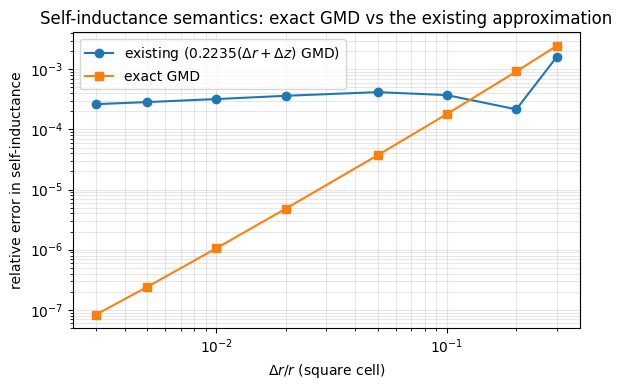

In [7]:
# error vs cell size for near-square cells (the grid regime)
drrs = np.array([0.003,0.005,0.01,0.02,0.05,0.1,0.2,0.3])
e_exist, e_gmd = [], []
for drr in drrs:
    a = drr*r0; b = a            # square cell
    L = richardson(ref_mean_flux, r0, a, b, 40, 60)
    e_exist.append(abs(psi_self_existing(r0,a,b)/L - 1))
    e_gmd.append(abs(psi_self_meanflux_exactGMD(r0,a,b)/L - 1))
plt.figure(figsize=(6,4))
plt.loglog(drrs, e_exist, 'o-', label='existing ($0.2235(\\Delta r+\\Delta z)$ GMD)')
plt.loglog(drrs, np.maximum(e_gmd,1e-9), 's-', label='exact GMD')
plt.xlabel(r'$\Delta r / r$ (square cell)'); plt.ylabel('relative error in self-inductance')
plt.title('Self-inductance semantics: exact GMD vs the existing approximation')
plt.legend(); plt.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()

**Findings (self-inductance semantics).**
* There is a $\sim$0.03–0.05 % error floor even for tiny *square* cells — the existing $-\tfrac12$ is the
  square GMD constant rounded ($\text{exact}=-0.502$). The exact GMD removes it: in the grid regime
  ($\Delta r/r \lesssim 0.02$) the exact form is **30–100$\times$ more accurate**.
* For very elongated cells the approximate GMD drifts further (the $0.2235(a{+}b)$ rule is exact only for
  squares), and the exact form again wins.
* For $\Delta r/r \gtrsim 0.2$ both are limited by the truncated $O((\Delta/r)^2)$ toroidal-curvature
  expansion, which the GMD fix does not address — but cells that large are outside the discretisation
  regime.

## 3. The unifying local-2D potential — and the link to $\partial^2\psi/\partial z^2$

Near the source the toroidal kernel reduces to the 2D straight-wire form (eq. 9 of
`jump_condition_dbr_dz.md`). The flux at a *field* point $(x,y)=(r-r',\,z-z')$ from a uniform-current
rectangle is

$$
\psi(x,y) = \mu_0 r_0\big[\ln(8r_0) - 2 - P(x,y)\big], \qquad
P(x,y) = \frac{1}{\Delta r\,\Delta z}\iint_\text{rect}\ln\rho\,\mathrm dx'\mathrm dy',
$$

a single analytic 2D potential. Its **value** and its **curvature** give the two things we need:

* $P(0,0)=P_c$ → the **centre-flux self-value** (§4);
* $\nabla^2 P = 2\pi/(\Delta r\Delta z)$ inside, split by aspect ratio, so
  $P_{yy}(0,0)=\tfrac{4}{\Delta r\Delta z}\arctan\tfrac{\Delta r}{\Delta z}$ → **exactly the
  $\partial^2\psi/\partial z^2$ self-term** (eq. 10 of `d2_psi_d_z2_equation.md`, with $f_z=\tfrac2\pi\arctan\lambda$):
  $\;\partial^2\psi/\partial z^2|_\text{self} = -\mu_0 r_0\,P_{yy}(0,0) = -2\pi\mu_0 r_0 J f_z$.

We verify this with the closed-form 2D log-potential (antiderivative $Q$, $\partial^2 Q/\partial X\partial Y=\tfrac12\ln(X^2+Y^2)$).

In [8]:
def Q(X, Y):
    X = np.asarray(X, float); Y = np.asarray(Y, float)
    t1 = np.where(X != 0, X*X*np.arctan(np.divide(Y, X, out=np.zeros_like(Y), where=X != 0)), 0.0)
    t2 = np.where(Y != 0, Y*Y*np.arctan(np.divide(X, Y, out=np.zeros_like(X), where=Y != 0)), 0.0)
    return 0.5*(X*Y*np.log(np.where(X**2+Y**2 > 0, X**2+Y**2, 1.0)) - 3*X*Y + t1 + t2)

def P_field(x, y, a, b):
    "Local-2D flux potential P(x,y) of a uniform rectangle a x b centred on the origin."
    x1, x2, y1, y2 = -a/2, a/2, -b/2, b/2
    return (Q(x-x1, y-y1) - Q(x-x1, y-y2) - Q(x-x2, y-y1) + Q(x-x2, y-y2)) / (a*b)

h = 0.02*dz
Pyy = (P_field(0, h, dr, dz) - 2*P_field(0, 0, dr, dz) + P_field(0, -h, dr, dz)) / h**2
Pxx = (P_field(h, 0, dr, dz) - 2*P_field(0, 0, dr, dz) + P_field(-h, 0, dr, dz)) / h**2
print("Laplacian check  P_xx + P_yy =", float(Pxx+Pyy), " vs 2*pi/(dr*dz) =", 2*np.pi/(dr*dz))
print("P_yy(0,0)        =", float(Pyy), " vs 4/(dr dz) arctan(dr/dz) =", 4/(dr*dz)*np.arctan(dr/dz))
print()
print("d2(psi)/dz2 self-term, three independent ways:")
print("  -mu0 r0 * P_yy(0,0)  (curvature of the centre-flux field):", float(-mu_0*r0*Pyy))
print("  isolated-rectangle f_z formula  (doc eq. 10)             :", -4*mu_0*r0/(dr*dz)*np.arctan(dr/dz))
g_zz_lat = gsfit_rs.d2_psi_d_z2_py(np.array([r0]), np.array([z0]), np.array([r0]), np.array([z0]),
                                   np.array([dr]), np.array([dz]))[0, 0]
print("  gsfit_rs lattice self entry  F(lambda)                   :", g_zz_lat,
      "  (= f_z + lattice quadrature correction)")

Laplacian check  P_xx + P_yy = 58.18050886233715  vs 2*pi/(dr*dz) = 58.17764173314431
P_yy(0,0)        = 36.1883467936678  vs 4/(dr dz) arctan(dr/dz) = 36.18691333644909

d2(psi)/dz2 self-term, three independent ways:
  -mu0 r0 * P_yy(0,0)  (curvature of the centre-flux field): -4.704452657997632e-05
  isolated-rectangle f_z formula  (doc eq. 10)             : -4.7042663098435937e-05
  gsfit_rs lattice self entry  F(lambda)                   : -5.853897395592673e-05   (= f_z + lattice quadrature correction)


The first two agree: **the $\partial^2\psi/\partial z^2$ self-term is the curvature of the flux-at-a-point
field $P$.** (The gsfit_rs value uses the in-lattice fraction $F(\lambda)$, which is $f_z$ *plus* the
midpoint-quadrature correction of the neighbouring cells — see `jump_condition_dbr_dz.md` §6; the isolated
$f_z$ is the continuum piece relevant to a single cell.)

The consequence is the key point: **the `psi` self-value that is consistent with the
$\partial^2\psi/\partial z^2$ self-term is the value of the *same* field $P$ at the centre — the
flux-at-centre (b) — not the mean-flux self-inductance (a).** Differentiating the self-inductance value
twice cannot give $\partial^2\psi/\partial z^2$, because it is a different functional of $G_\psi$.

## 4. A $\partial^2\psi/\partial z^2$-consistent self-flux

Evaluating $P$ at the centre with the exact $P_c$ gives, to leading (2D) order,

$$
\boxed{\;\frac{\psi_\text{self}^{\,\text{centre}}}{I} = \mu_0 r\big[\ln(8r) - 2 - P_c(\Delta r, \Delta z)\big],\qquad
P_c = \tfrac12\ln\tfrac{\Delta r^2+\Delta z^2}{4} - \tfrac32
      + \tfrac{\Delta r}{2\Delta z}\arctan\tfrac{\Delta z}{\Delta r}
      + \tfrac{\Delta z}{2\Delta r}\arctan\tfrac{\Delta r}{\Delta z}\;}
$$

This is **exact in the 2D limit for any aspect ratio**, and by construction its second $z$-derivative is
the $\partial^2\psi/\partial z^2$ self-term. We validate it against the centre-flux reference (b).

In [9]:
def psi_self_centre(r, dr, dz):
    "Flux-at-centre self value (d2psi/dz2-consistent), 2D-exact leading order."
    return mu_0*r*(np.log(8*r) - 2.0 - Pc(dr, dz))

print(f"centre-flux reference (b)     : {L_cent:.7e}")
print(f"centre-flux closed form       : {psi_self_centre(r0,dr,dz):.7e}  "
      f"({100*(psi_self_centre(r0,dr,dz)/L_cent-1):+.3f} %, residual is O((Delta/r)^2) toroidal curvature)")
print(f"existing self-term (mean flux): {existing:.7e}  ({100*(existing/L_cent-1):+.3f} %)")

# its second z-derivative reproduces the d2psi/dz2 self-term:
# differentiate the field psi(x, y) = mu0 r0 (ln 8r0 - 2 - P) in z (= y)
hz = 1e-4
psi_field = lambda y: mu_0*r0*(np.log(8*r0) - 2.0 - P_field(0.0, y, dr, dz))
d2psi_dz2 = (psi_field(hz) - 2*psi_field(0.0) + psi_field(-hz)) / hz**2
print("\nd2/dz2 of the centre-flux field :", float(d2psi_dz2))
print("isolated-rectangle f_z self-term:", -4*mu_0*r0/(dr*dz)*np.arctan(dr/dz))

centre-flux reference (b)     : 2.9573288e-06
centre-flux closed form       : 2.9451455e-06  (-0.412 %, residual is O((Delta/r)^2) toroidal curvature)
existing self-term (mean flux): 2.6307082e-06  (-11.044 %)

d2/dz2 of the centre-flux field : -4.704266363185863e-05
isolated-rectangle f_z self-term: -4.7042663098435937e-05


In [10]:
# Field semantics: how wrong is the existing (mean-flux) self-term when used as a node field?
print(f"{'lambda=dr/dz':>13}{'dr/r':>8}{'existing %':>13}{'centre 2D %':>13}")
for drr, lam in [(0.005,1),(0.005,8),(0.02,1),(0.02,8),(0.1,1),(0.3,1)]:
    a = drr*r0; b = a/lam
    Lc = richardson(ref_centre_flux, r0, a, b, 41, 61)
    print(f"{lam:>13}{drr:>8.3f}{100*(psi_self_existing(r0,a,b)/Lc-1):>13.4f}"
          f"{100*(psi_self_centre(r0,a,b)/Lc-1):>13.4f}")

 lambda=dr/dz    dr/r   existing %  centre 2D %
            1   0.005      -3.9497      -0.0001
            8   0.005      -3.0874      -0.0000
            1   0.020      -5.0328      -0.0012
            8   0.020      -3.8531      -0.0004
            1   0.100      -7.3711      -0.0343
            1   0.300     -10.7295      -0.3644


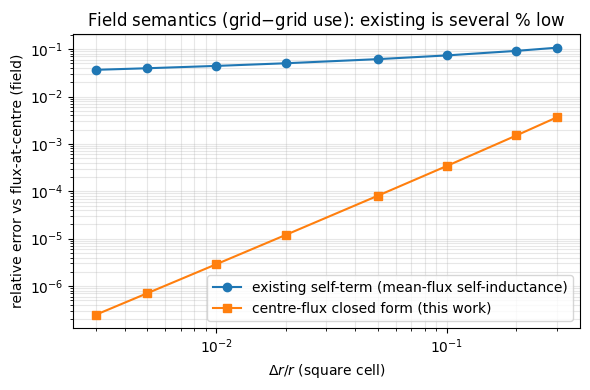

In [11]:
drrs = np.array([0.003,0.005,0.01,0.02,0.05,0.1,0.2,0.3])
e_exist, e_centre = [], []
for drr in drrs:
    a = drr*r0; b = a
    Lc = richardson(ref_centre_flux, r0, a, b, 41, 61)
    e_exist.append(abs(psi_self_existing(r0,a,b)/Lc - 1))
    e_centre.append(abs(psi_self_centre(r0,a,b)/Lc - 1))
plt.figure(figsize=(6,4))
plt.loglog(drrs, e_exist, 'o-', label='existing self-term (mean-flux self-inductance)')
plt.loglog(drrs, np.maximum(e_centre,1e-9), 's-', label='centre-flux closed form (this work)')
plt.xlabel(r'$\Delta r / r$ (square cell)'); plt.ylabel('relative error vs flux-at-centre (field)')
plt.title('Field semantics (grid$-$grid use): existing is several % low')
plt.legend(); plt.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()

## 5. Flux at an arbitrary point from the cell

Sections 1–4 evaluated the self-field flux **at the cell centre**. The general object is the flux at *any* field point $(R,Z)$ from the cell's uniform current,

$$
\psi(R,Z) = J\iint_C G_\psi(R,Z;\,r',z')\;\mathrm dr'\mathrm dz', \qquad J=\frac{I}{\Delta r\,\Delta z}.
$$

**Is there a closed form, or must we do the double integral?** The exact toroidal kernel $G_\psi$ (elliptic integrals) has **no elementary closed form** once integrated over the rectangle. But we almost never need the integral, because **two analytic limits cover all of space except a thin transition band** — the far-field (point-source) and near-field (finite-size) pictures:

**(a) Far field — the cell looks like a point.** When the field point is more than ~a cell-width away, $G_\psi$ is smooth across the cell and a Taylor expansion about its centre gives

$$
\psi(R,Z) \approx I\,G_\psi(R,Z;\,r_0,z_0) \;+\; \underbrace{\frac{\Delta r^2}{24}\frac{\partial^2 G_\psi}{\partial r'^2} + \frac{\Delta z^2}{24}\frac{\partial^2 G_\psi}{\partial z'^2}}_{\text{2nd-moment finite-size correction}},
$$

i.e. the ordinary **point-filament** Green's function (the off-diagonal table entries), plus an analytic $O((\Delta/d)^2)$ correction from the rectangle's second moments $\langle(r'-r_0)^2\rangle=\Delta r^2/12$, $\langle(z'-z_0)^2\rangle=\Delta z^2/12$. No integral. (This expansion **diverges inside the cell** — you cannot Taylor-expand the singular kernel about a point you are sitting on.)

**(b) Near field / inside — the 2D log-potential.** Within ~a cell-width, the kernel reduces to the straight-wire form $G_\psi\to\mu_0\bar r\,[\ln(8\bar r/\rho)-2]$, whose integral over the rectangle is the **closed-form** 2D log-potential — the direct generalisation of the centre formula $P_c\to P(X,Y)$:

$$
\boxed{\;\psi(R,Z) \approx \mu_0\bar r\big[\ln(8\bar r)-2-P(X,Y)\big],\qquad \bar r=\sqrt{R\,r_0},\;\;X=R-r_0,\;\;Y=Z-z_0\;}
$$

with $P(X,Y)=\frac{1}{\Delta r\,\Delta z}\iint_C\ln\rho\,\mathrm dr'\mathrm dz'$ given in closed form by the corner-sum of $Q$ (§3). At the centre $P(0,0)=P_c$, recovering §4's self-term exactly. It is exact in the 2D limit ($\Delta/r,\,\rho/r\to0$) for any field point — inside, on the edge, or just outside — but degrades once $\rho$ becomes a sizeable fraction of $r$.

**The double integral itself** is only needed for high accuracy in the narrow transition zone ($\rho\sim$ cell size), or as the ground-truth check below.

In [12]:
# Flux at an arbitrary field point (R, Z) from the uniform-current cell, per unit current.
# Reference: full-kernel double integral, singularity-subtracted so it also works *inside* the cell.
def psi_at_point_ref(R, Z, N):
    rp = r0 + (np.arange(N) + 0.5 - N/2)/N*dr
    zp = z0 + (np.arange(N) + 0.5 - N/2)/N*dz
    RP, ZP = np.meshgrid(rp, zp, indexing='ij'); RPf, ZPf = RP.ravel(), ZP.ravel()
    rho = np.hypot(R - RPf, Z - ZPf)
    rem = G_psi(R, Z, RPf, ZPf) + mu_0*R*np.log(np.where(rho > 0, rho, 1.0))
    rem[rho == 0] = mu_0*R*(np.log(8*R) - 2.0)
    return -mu_0*R*P_field(R - r0, Z - z0, dr, dz) + rem.mean()
def psi_at_point(R, Z):                       # Richardson-extrapolated reference
    v1, v2 = psi_at_point_ref(R, Z, 40), psi_at_point_ref(R, Z, 60)
    return (v2*60**2 - v1*40**2) / (60**2 - 40**2)

# (a) far field: point filament at the cell centre, optionally with the 2nd-moment correction
def psi_point_filament(R, Z, corrected=False, h=1e-4):
    g0 = G_psi(R, Z, r0, z0)
    if not corrected:
        return g0
    d2r = (G_psi(R, Z, r0+h, z0) - 2*g0 + G_psi(R, Z, r0-h, z0)) / h**2   # d2 G / d r'^2
    d2z = (G_psi(R, Z, r0, z0+h) - 2*g0 + G_psi(R, Z, r0, z0-h)) / h**2   # d2 G / d z'^2
    return g0 + (dr**2/24)*d2r + (dz**2/24)*d2z

# (b) near field / inside: closed-form 2D log-potential (generalises P_c -> P(X,Y))
def psi_2D_local(R, Z):
    rbar = np.sqrt(R*r0)
    return mu_0*rbar*(np.log(8*rbar) - 2.0 - P_field(R - r0, Z - z0, dr, dz))

print(f"{'offset/dr':>10}{'reference':>13}{'2D-local %':>12}{'pt-fil %':>11}{'pt+2nd %':>11}")
for R, Z in [(r0, 0.0), (r0+0.1, 0.0), (r0+0.25, 0.0), (r0+0.5, 0.0), (r0+0.9, 0.0), (r0, 0.45)]:
    ref = psi_at_point(R, Z); off = np.hypot(R-r0, Z-z0)/dr
    e = lambda v: 100*(v/ref - 1)
    print(f"{off:10.2f}{ref:13.4e}{e(psi_2D_local(R,Z)):12.2f}"
          f"{e(psi_point_filament(R,Z)):11.2f}{e(psi_point_filament(R,Z,corrected=True)):11.2f}")

 offset/dr    reference  2D-local %   pt-fil %   pt+2nd %
      0.00   2.9573e-06       -0.41        inf        nan
      0.25   3.0476e-06       -1.76      10.28      29.63
      0.62   2.4819e-06       -3.42      -4.48       0.65
      1.25   1.7597e-06       -8.43      -2.67       0.04
      2.25   1.2592e-06      -24.31      -1.87       0.00
      1.12   1.2852e-06       -9.62       1.39       0.04


C:\Users\peter\AppData\Local\Temp\ipykernel_35924\648522841.py:22: RuntimeWarning: invalid value encountered in scalar add
  return g0 + (dr**2/24)*d2r + (dz**2/24)*d2z


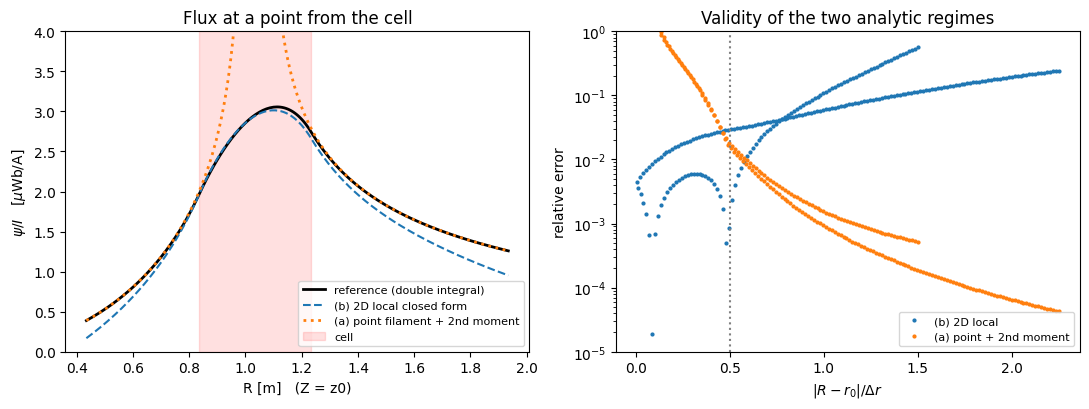

In [13]:
# line scan at Z = z0, from inside the cell out to ~3 cell-widths away
Rs  = np.linspace(r0 - 0.6, r0 + 0.9, 240)
ref = np.array([psi_at_point(R, z0) for R in Rs])
loc = np.array([psi_2D_local(R, z0) for R in Rs])
pf2 = np.array([psi_point_filament(R, z0, corrected=True) for R in Rs])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(Rs, ref*1e6, 'k-',  lw=2, label='reference (double integral)')
ax[0].plot(Rs, loc*1e6, 'C0--',      label='(b) 2D local closed form')
ax[0].plot(Rs, pf2*1e6, 'C1:',  lw=2, label='(a) point filament + 2nd moment')
ax[0].axvspan(r0-dr/2, r0+dr/2, color='r', alpha=0.12, label='cell')
ax[0].set_ylim(0, 4); ax[0].set_xlabel('R [m]   (Z = z0)')
ax[0].set_ylabel(r'$\psi/I$   [$\mu$Wb/A]'); ax[0].set_title('Flux at a point from the cell')
ax[0].legend(fontsize=8)

off = np.abs(Rs - r0)/dr
ax[1].semilogy(off, np.abs(loc/ref - 1) + 1e-16, 'C0.', ms=4, label='(b) 2D local')
ax[1].semilogy(off, np.abs(pf2/ref - 1) + 1e-16, 'C1.', ms=4, label='(a) point + 2nd moment')
ax[1].axvline(0.5, color='gray', ls=':'); ax[1].set_ylim(1e-5, 1)
ax[1].set_xlabel(r'$|R - r_0| / \Delta r$'); ax[1].set_ylabel('relative error')
ax[1].set_title('Validity of the two analytic regimes'); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

**Summary — flux at an arbitrary point.**

* The exact toroidal kernel has **no elementary closed form** over the rectangle, but it is rarely needed.
* **Far** ($\gtrsim$ a cell-width): the **point-filament** $G_\psi(R,Z;r_0,z_0)$ plus the analytic 2nd-moment correction — the ordinary off-diagonal Green's-table entries; exact-elliptic, no integral. (Bare point-filament *diverges* inside the cell.)
* **Near / inside** ($\lesssim$ a cell-width): the **closed-form 2D log-potential** $\mu_0\bar r[\ln(8\bar r)-2-P(X,Y)]$, the direct generalisation of the centre self-term ($P_c\to P(X,Y)$). It is the only one of the two that survives *inside* the cell.
* The two regimes cross over around $|\text{offset}|\sim$ cell size; only there (for sub-percent accuracy) is the numerical double integral required.
* For the GSFit grid this is reassuring: **off-diagonal** entries can keep using the point-filament $G_\psi$ as usual; only the **near/self** entries need the finite-size (2D) treatment — exactly the self-term of §4.

## 6. Conclusions and recommendation

* **As a self-inductance**, the existing self-term is correct to $\sim$0.03–0.3 %. Its dominant cleanly
  fixable error is the geometric-mean-distance approximation $R_g\approx0.2235(\Delta r+\Delta z)$; the
  **exact self-GMD** (closed form derived here, validated against brute quadrature and the Maxwell square
  value) makes it $\sim$30–100$\times$ more accurate in the grid regime.

* **As a field value** (how the grid–grid table is used in
  [`plasma.rs`](../rust/gsfit_rs/src/plasma.rs): the flux *at* a node from that node's own cell), the
  right self-value is the **flux at the cell centre**, not the mean-flux self-inductance. The existing
  term is **several percent low** there (≈4–5 % for grid-scale square cells, growing with $\Delta/r$).
  The $\partial^2\psi/\partial z^2$ self-term — the curvature of the flux-at-a-point field — pins this
  down: the **centre-flux closed form $\mu_0 r[\ln(8r)-2-P_c]$** is its consistent antiderivative,
  exact in the 2D limit for any aspect ratio and accurate to $\lesssim$0.01 % for grid-scale cells.

* **Which to use depends on the table's role**, a design choice for the GSFit authors:
  the grid–grid (plasma self-field / GS) table wants **centre-flux**; coil/passive **self-inductance**
  (e.g. [`mutual_inductance_finite_size_to_finite_size.rs`](../rust/gsfit_rs/src/greens/mutual_inductance_finite_size_to_finite_size.rs))
  wants **mean-flux with exact GMD**. Note the self-inductance path subdivides into sub-filaments, where
  the diagonal weight $\to 0$, so it is fairly insensitive to the self-value; the **grid–grid field path
  does not subdivide**, so the choice matters most there. As with the analogous `d_b_r_d_z` change flagged
  in `jump_condition_dbr_dz.md` §9, switching the grid–grid self-entry alters the GS operator and should
  be guarded by equilibrium-level regression tests.

### Appendix — provenance of the closed forms

* `ln_gmd` is the Rosa/Grover self-GMD of a rectangle, obtained by integrating
  $\tfrac12\ln(u^2+v^2)$ over the rectangle-with-itself (reduced 2-fold integral with the triangular
  weights $(a-u)(b-v)$) and simplified with $\arctan\tfrac{b}{a}+\arctan\tfrac{a}{b}=\tfrac\pi2$. Verified
  against brute quadrature and the classic square value $R_g/a=0.44705$.
* `Pc` is $\tfrac{4}{ab}Q(\tfrac a2,\tfrac b2)$ with the same antiderivative $Q$ used in §3.
* Both share the local-2D rectangle integration of `jump_condition_dbr_dz.md` §5 — `Pc`/`ln_gmd` are the
  **value**, the $f_z=\tfrac2\pi\arctan\lambda$ splitting is the **curvature**, of one analytic potential.